In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
import numpy as np
import scipy.stats as stats

%store -r regs_2016
%store -r regs_2019
%store -r regs_2022
%store -r regs_2016_nr
%store -r regs_2019_nr
%store -r regs_2022_nr
%store -r regs_2022n
%store -r parameters_2016
%store -r parameters_2019
%store -r parameters_2022
%store -r parameters_2016_nr
%store -r parameters_2019_nr
%store -r parameters_2022_nr
%store -r parameters_2022n


os.chdir('/Users/fogellmcmuffin/Documents/thesis/_replication/')    # Working dir

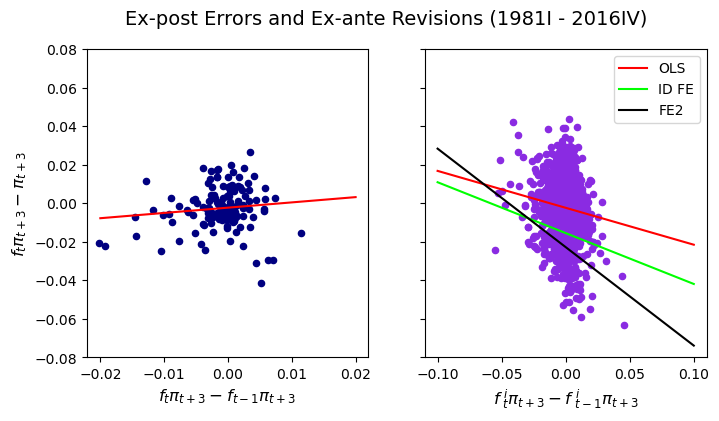

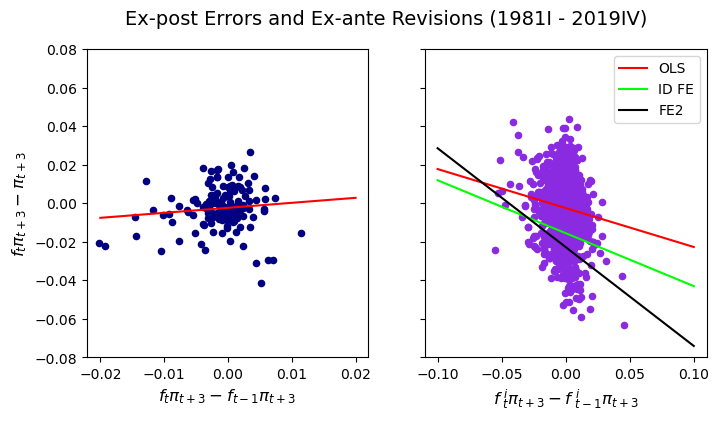

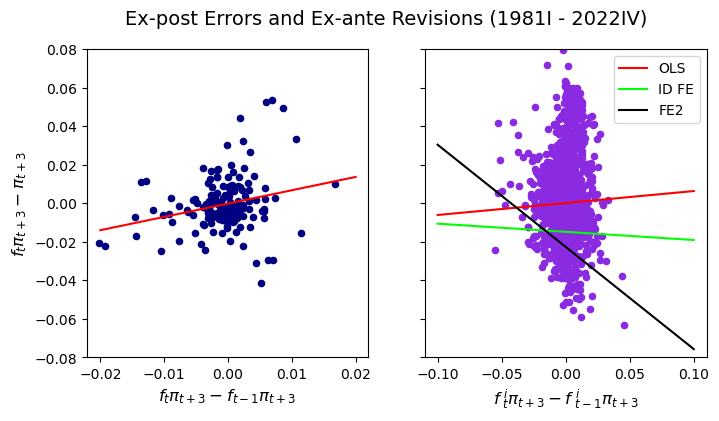

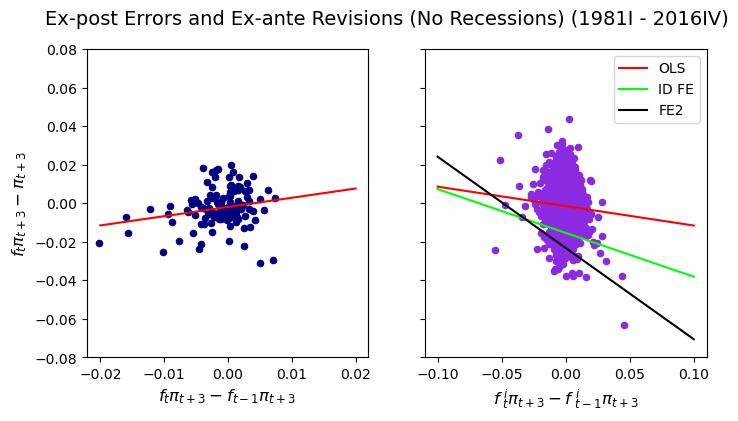

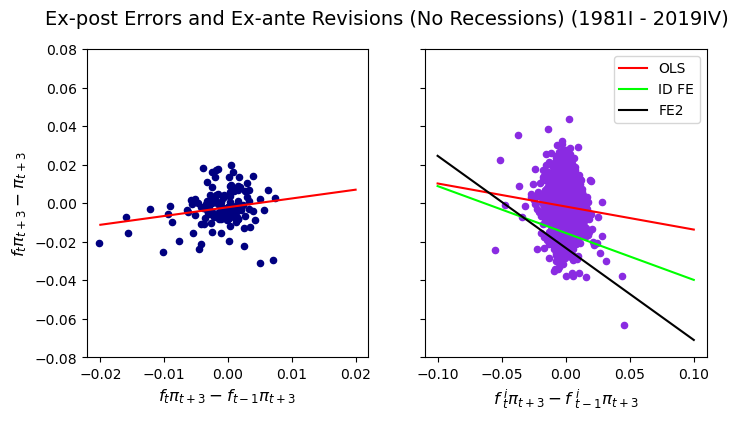

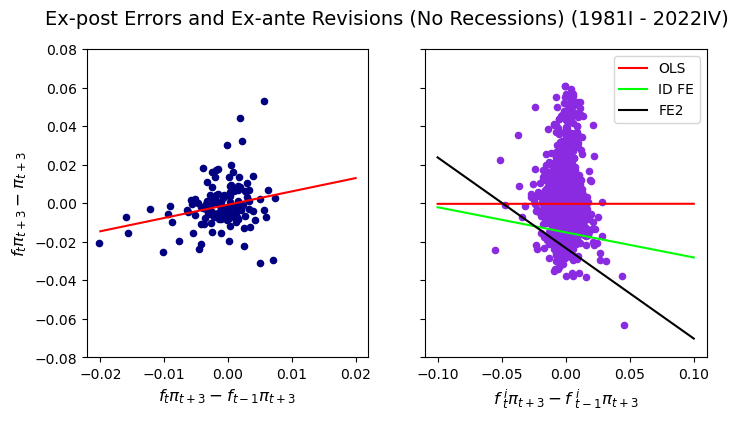

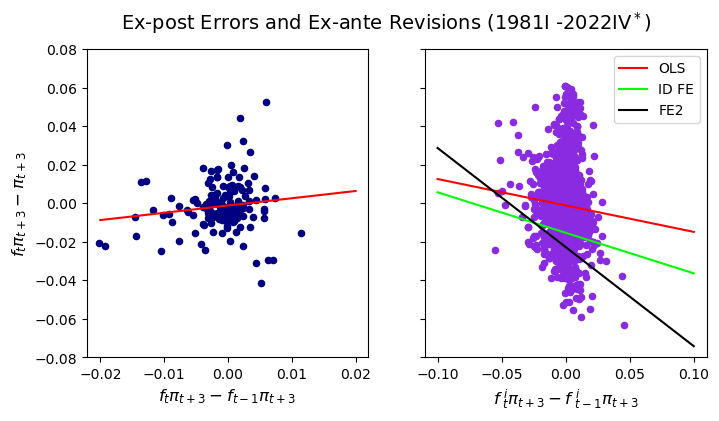

In [2]:
#########################
    ## Rev & Errors ##
#########################    
def rev_errs(date, regs):
    mean_spf_trim = pd.read_csv('cleaned_data/mean_spf_trim.csv')
    ind_spf_trim = pd.read_csv('cleaned_data/ind_spf_trim.csv')
    mean_spf_trim = mean_spf_trim.loc[(mean_spf_trim['DATE'] >= '1981-09-30') & (mean_spf_trim['DATE'] <= f'{date}')]
    ind_spf_trim = ind_spf_trim.loc[(ind_spf_trim['DATE'] >= '1981-09-30') & (ind_spf_trim['DATE'] <= f'{date}')]

    fig, (axm, axi) = plt.subplots(nrows=1, sharey=True, ncols=2, figsize=(8, 4))
    fig.suptitle(f'Ex-post Errors and Ex-ante Revisions (1981I - {str(date)[0:4]}IV)', fontsize=14)
    plt.ylim(-0.08, 0.08)

    xm = mean_spf_trim['r_t3'][1:]
    ym = mean_spf_trim['e_t3'][1:]

    axm.scatter(xm, ym, c='navy', alpha=1, s=20)
    model_m = regs[0][3].params[0] + regs[0][3].params[1] * np.linspace(-0.02, 0.02)
    axm.plot(np.linspace(-0.02, 0.02),  model_m, color='red', lw=1.5)

    axm.set_xlabel(r'$f_{t}\pi_{t+3} - f_{t-1}\pi_{t+3}$', fontsize=12)
    axm.set_ylabel(r'$f_{t}\pi_{t+3}-\pi_{t+3}$', fontsize=12)

    ### Individual ###
    xi = ind_spf_trim['r_t3']
    yi = ind_spf_trim['e_t3']
    model_p = regs[1][3].params[0] + regs[1][3].params[1] * np.linspace(-0.1, 0.1)
    model_fe = regs[2][3].params[0] + regs[2][3].params[1] * np.linspace(-0.1, 0.1)
    model_fe2 = regs[3][3].params[0] + regs[3][3].params[1] * np.linspace(-0.1, 0.1)

    axi.scatter(xi, yi, c='blueviolet', alpha=1, s=20)
    axi.plot(np.linspace(-0.1, 0.1), model_p, label='OLS', color='red', lw=1.5)
    axi.plot(np.linspace(-0.1, 0.1), model_fe, label='ID FE', color='lime', lw=1.5)
    axi.plot(np.linspace(-0.1, 0.1), model_fe2, label='FE2', color='black', lw=1.5)

    axi.set_xlabel(r'$f^{\ i}_{\ t}\pi_{t+3} - f^{\ i}_{\ t-1}\pi_{t+3}$', fontsize=12)
    axi.legend()

    plt.show()
    fig.savefig(f'output/figures/rev_errors/re_scat_{str(date)[0:4]}.png', dpi=200)


def rev_errs_nr(date, regs):
    mean_spf_trim_nr = pd.read_csv('cleaned_data/mean_spf_trim_nr.csv')
    ind_spf_trim_nr = pd.read_csv('cleaned_data/ind_spf_trim_nr.csv')
    mean_spf_trim_nr = mean_spf_trim_nr.loc[(mean_spf_trim_nr['DATE'] >= '1981-09-30') & (mean_spf_trim_nr['DATE'] <= f'{date}')]
    ind_spf_trim_nr = ind_spf_trim_nr.loc[(ind_spf_trim_nr['DATE'] >= '1981-09-30') & (ind_spf_trim_nr['DATE'] <= f'{date}')]

    fig, (axm, axi) = plt.subplots(nrows=1, sharey=True, ncols=2, figsize=(8, 4))
    fig.suptitle(f'Ex-post Errors and Ex-ante Revisions (No Recessions) (1981I - {str(date)[0:4]}IV)', fontsize=14)
    plt.ylim(-0.08, 0.08)

    xm = mean_spf_trim_nr['r_t3'][1:]
    ym = mean_spf_trim_nr['e_t3'][1:]

    axm.scatter(xm, ym, c='navy', alpha=1, s=20)
    model_m = regs[0][3].params[0] + regs[0][3].params[1] * np.linspace(-0.02, 0.02)
    axm.plot(np.linspace(-0.02, 0.02),  model_m, color='red', lw=1.5)

    axm.set_xlabel(r'$f_{t}\pi_{t+3} - f_{t-1}\pi_{t+3}$', fontsize=12)
    axm.set_ylabel(r'$f_{t}\pi_{t+3}-\pi_{t+3}$', fontsize=12)

    ### Individual ###
    xi = ind_spf_trim_nr['r_t3']
    yi = ind_spf_trim_nr['e_t3']
    model_p = regs[1][3].params[0] + regs[1][3].params[1] * np.linspace(-0.1, 0.1)
    model_fe = regs[2][3].params[0] + regs[2][3].params[1] * np.linspace(-0.1, 0.1)
    model_fe2 = regs[3][3].params[0] + regs[3][3].params[1] * np.linspace(-0.1, 0.1)

    axi.scatter(xi, yi, c='blueviolet', alpha=1, s=20)
    axi.plot(np.linspace(-0.1, 0.1), model_p, label='OLS', color='red', lw=1.5)
    axi.plot(np.linspace(-0.1, 0.1), model_fe, label='ID FE', color='lime', lw=1.5)
    axi.plot(np.linspace(-0.1, 0.1), model_fe2, label='FE2', color='black', lw=1.5)

    axi.set_xlabel(r'$f^{\ i}_{\ t}\pi_{t+3} - f^{\ i}_{\ t-1}\pi_{t+3}$', fontsize=12)
    axi.legend()

    plt.show()
    fig.savefig(f'output/figures/rev_errors/re_scat_{str(date)[0:4]}_nr.png', dpi=200)


def rev_errs22(date, regs):
    mean_spf_trim22 = pd.read_csv('cleaned_data/mean_spf_trim22.csv')
    ind_spf_trim22 = pd.read_csv('cleaned_data/ind_spf_trim22.csv')
    mean_spf_trim22 = mean_spf_trim22.loc[(mean_spf_trim22['DATE'] >= '1981-09-30') & (mean_spf_trim22['DATE'] <= f'{date}')]
    ind_spf_trim22 = ind_spf_trim22.loc[(ind_spf_trim22['DATE'] >= '1981-09-30') & (ind_spf_trim22['DATE'] <= f'{date}')]

    fig, (axm, axi) = plt.subplots(nrows=1, sharey=True, ncols=2, figsize=(8, 4))
    fig.suptitle(r'Ex-post Errors and Ex-ante Revisions (1981I -2022IV$^*$)', fontsize=14)
    plt.ylim(-0.08, 0.08)

    xm = mean_spf_trim22['r_t3'][1:]
    ym = mean_spf_trim22['e_t3'][1:]

    axm.scatter(xm, ym, c='navy', alpha=1, s=20)
    model_m = regs[0][3].params[0] + regs[0][3].params[1] * np.linspace(-0.02, 0.02)
    axm.plot(np.linspace(-0.02, 0.02),  model_m, color='red', lw=1.5)

    axm.set_xlabel(r'$f_{t}\pi_{t+3} - f_{t-1}\pi_{t+3}$', fontsize=12)
    axm.set_ylabel(r'$f_{t}\pi_{t+3}-\pi_{t+3}$', fontsize=12)

    ### Individual ###
    xi = ind_spf_trim22['r_t3']
    yi = ind_spf_trim22['e_t3']
    model_p = regs[1][3].params[0] + regs[1][3].params[1] * np.linspace(-0.1, 0.1)
    model_fe = regs[2][3].params[0] + regs[2][3].params[1] * np.linspace(-0.1, 0.1)
    model_fe2 = regs[3][3].params[0] + regs[3][3].params[1] * np.linspace(-0.1, 0.1)

    axi.scatter(xi, yi, c='blueviolet', alpha=1, s=20)
    axi.plot(np.linspace(-0.1, 0.1), model_p, label='OLS', color='red', lw=1.5)
    axi.plot(np.linspace(-0.1, 0.1), model_fe, label='ID FE', color='lime', lw=1.5)
    axi.plot(np.linspace(-0.1, 0.1), model_fe2, label='FE2', color='black', lw=1.5)

    axi.set_xlabel(r'$f^{\ i}_{\ t}\pi_{t+3} - f^{\ i}_{\ t-1}\pi_{t+3}$', fontsize=12)
    axi.legend()

    plt.show()
    fig.savefig(f'output/figures/rev_errors/re_scat_2022_ncovid.png', dpi=200)



rev_errs('2016-12-31', regs_2016)
rev_errs('2019-12-31', regs_2019)
rev_errs('2022-12-31', regs_2022)
rev_errs_nr('2016-12-31', regs_2016_nr)
rev_errs_nr('2019-12-31', regs_2019_nr)
rev_errs_nr('2022-12-31', regs_2022_nr)
rev_errs22('2022-12-31', regs_2022n)

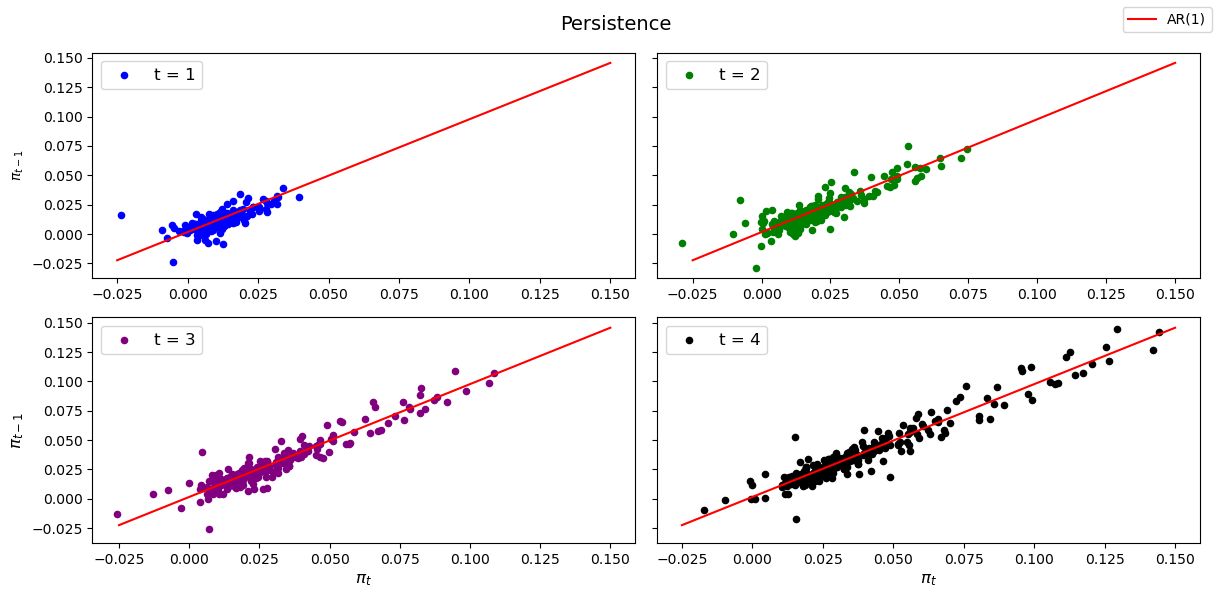

In [3]:
#####################
  ## Autoregg. ##
#####################
vintage_trim = pd.read_csv('cleaned_data/vintage_trim.csv')
vintage_trim = vintage_trim.set_index(pd.to_datetime(vintage_trim['DATE']))

vintage_trim = vintage_trim.loc[(vintage_trim['DATE'] >= '1965-06-30') & (vintage_trim['DATE'] <= '2022-12-31')]
vintage_trim = vintage_trim[['t0', 't1', 't2', 't3', 't4', 'rec']]

model0 = regs_2022[4].params[0] + regs_2022[4].params[1] * np.linspace(-0.025, 0.150)

fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 6), sharey=True,)
fig.suptitle('Persistence', fontsize=14)

ax0.scatter(vintage_trim['t0']['1965-09-30':], vintage_trim['t0'].shift(1)['1965-09-30':], c='blue', label=r't = 1', alpha=1, s=20)
ar = ax0.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5, label='AR(1)')
ax0.set_ylabel(r'$\pi_{t-1}$', fontsize=10)
ax0.legend(['t = 1'], fontsize=12)

ax1.scatter(vintage_trim['t1']['1965-09-30':], vintage_trim['t1'].shift(1)['1965-09-30':], c='green', label='t = 2', alpha=1, s=20)
ax1.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5)
ax1.legend(['t = 2'], fontsize=12)

ax2.scatter(vintage_trim['t2']['1965-09-30':], vintage_trim['t2'].shift(1)['1965-09-30':], c='purple', label='t = 3', alpha=1, s=20)
ax2.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5)
ax2.set_ylabel(r'$\pi_{t-1}$', fontsize=12)
ax2.set_xlabel(r'$\pi_t$', fontsize=12)
ax2.legend(['t = 3'], fontsize=12)

ax3.scatter(vintage_trim['t3']['1965-09-30':], vintage_trim['t3'].shift(1)['1965-09-30':], c='black', label='t = 4', alpha=1, s=20)
ax3.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5)
ax3.set_xlabel(r'$\pi_t$', fontsize=12)
ax3.legend(['t = 4'], fontsize=12)

fig.legend(handles=ar)
plt.tight_layout()
plt.show()
fig.savefig('output/figures/ar_scat.png', dpi=200)

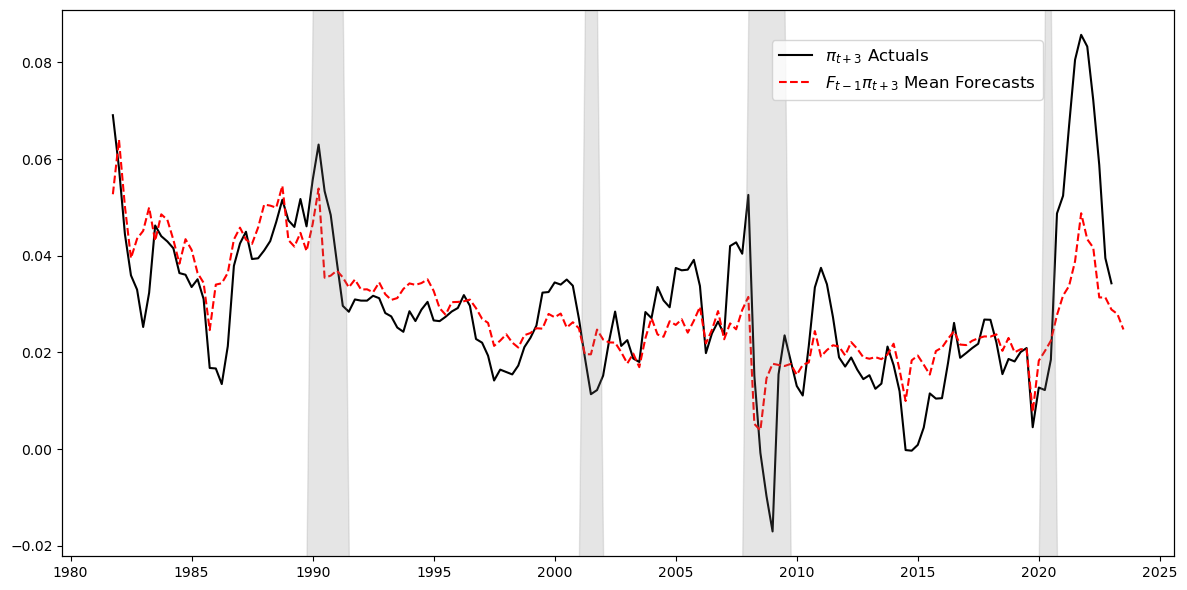

In [4]:
#####################
## Actuals vs Mean ##
#####################
mean_spf_trim = pd.read_csv('cleaned_data/mean_spf_trim.csv')
vintage_trim = pd.read_csv('cleaned_data/vintage_trim.csv')

vintage_trim['DATE'] = pd.to_datetime(vintage_trim['DATE'])
mean_spf_trim['DATE'] = pd.to_datetime(mean_spf_trim['DATE'])
vintage_trim = vintage_trim.loc[(vintage_trim['DATE'] >= '1981-09-01') & (vintage_trim['DATE'] <= '2022-12-31')]  # Filter data
vintage_trim = vintage_trim.set_index('DATE')
mean_spf_trim = mean_spf_trim.set_index('DATE')

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actuals and forecasts
ax.plot(vintage_trim.index, vintage_trim['t3'], color="k", lw=1.5, label=r'$\pi_{t+3}$ Actuals')
ax.plot(mean_spf_trim.index, mean_spf_trim['f_t3'].shift(-3), color='red', linestyle='dashed', lw=1.5, label=r'$F_{t-1}\pi_{t+3}$ Mean Forecasts')

# Add recession shading
ax1 = ax.twinx()
ax1.fill_between(vintage_trim.index, 0, vintage_trim['rec'], color='grey', alpha=0.2)
ax1.set_ylim(0, 1)
ax1.get_yaxis().set_visible(False)

# Legend and formatting
fig.legend(loc='right', fontsize=12, bbox_to_anchor=(0.76, 0.75, 0.12, 0.25))
plt.tight_layout()
plt.show()
fig.savefig('output/figures/act_errors_line.png', dpi=200)

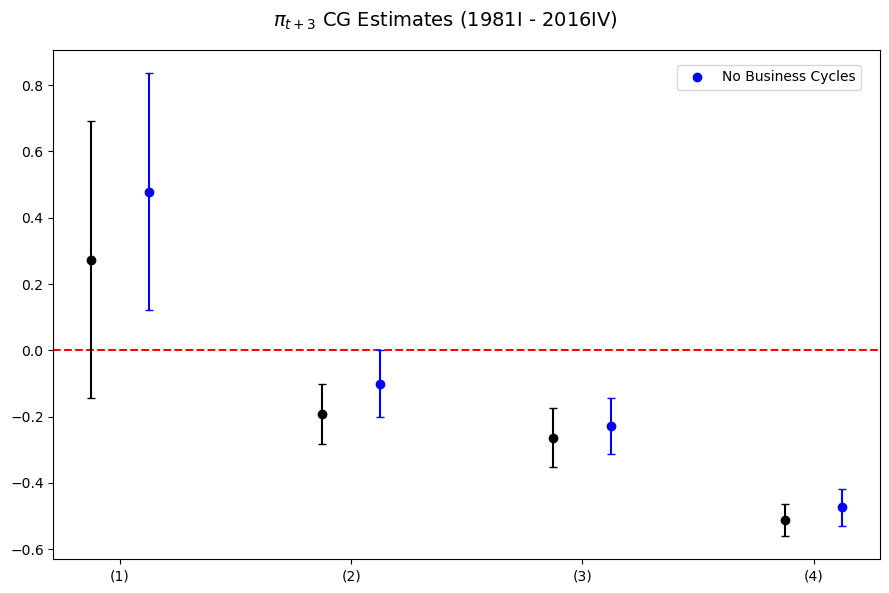

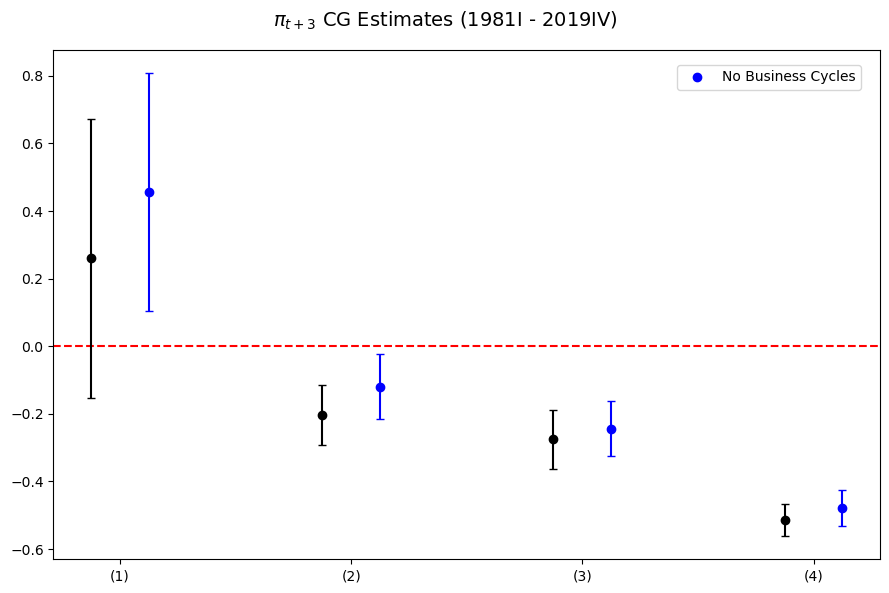

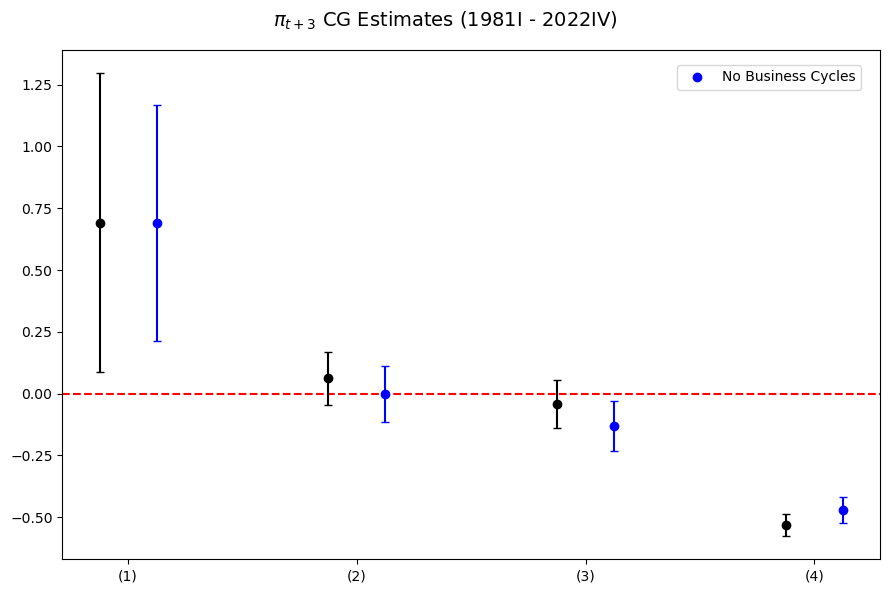

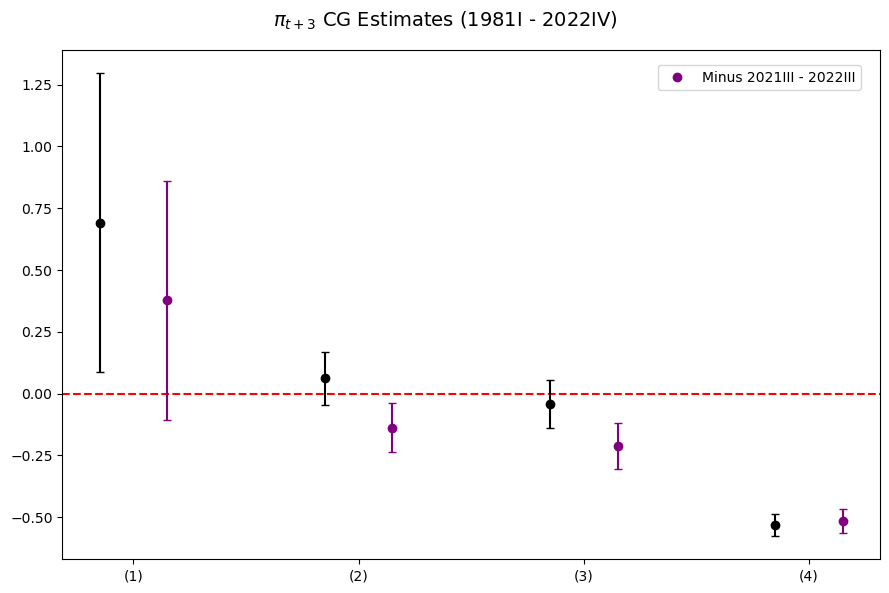

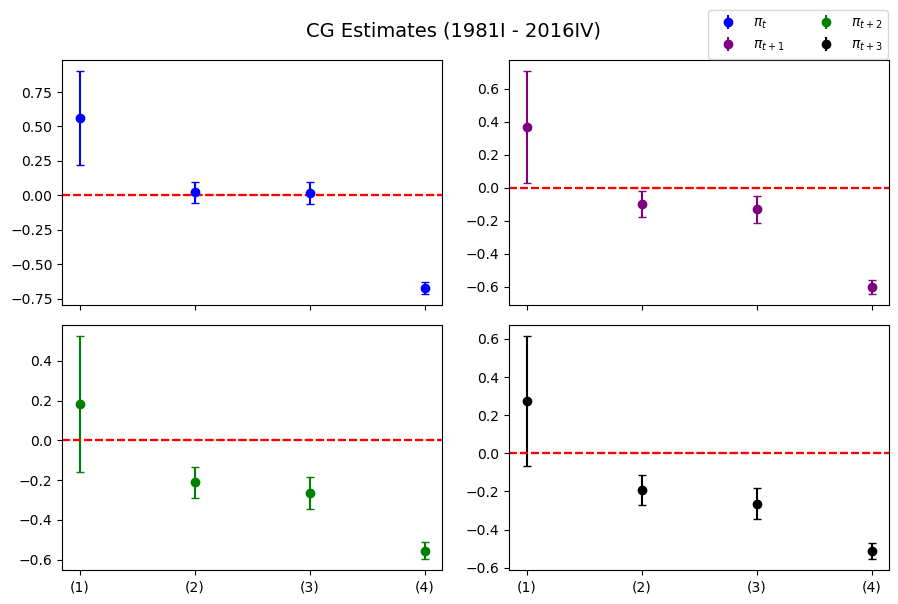

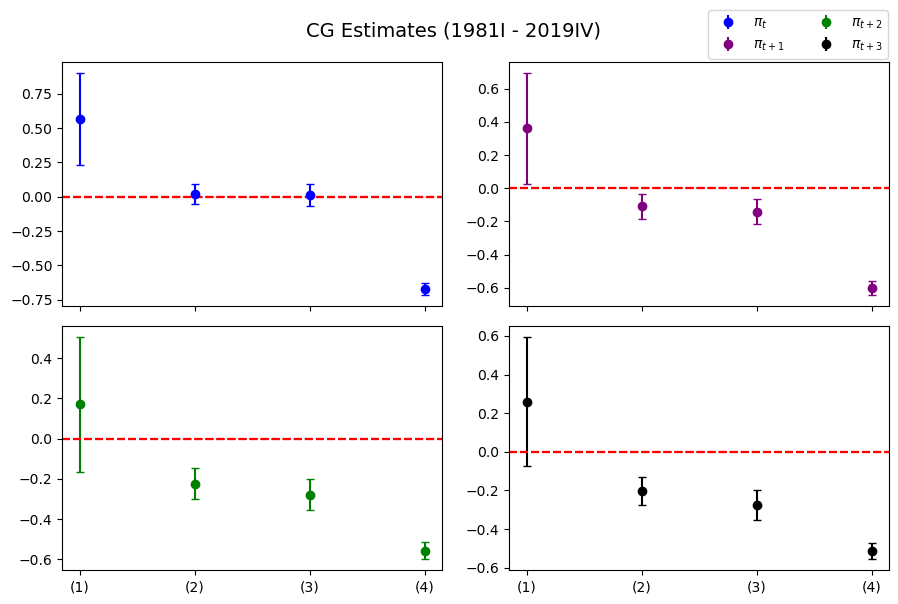

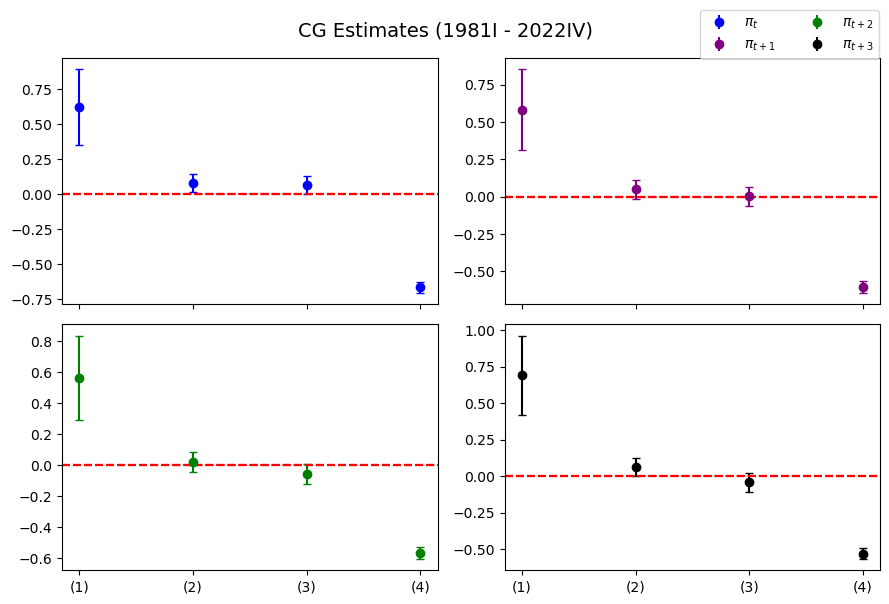

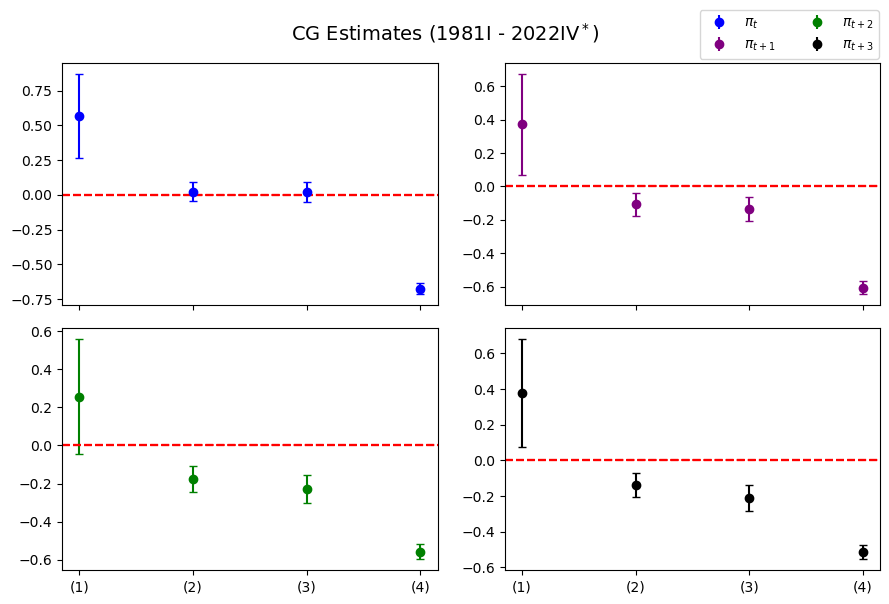

In [5]:
######################
   ## Estimates ##
######################
def est_plot(date, regs, regs_nr):
   fig, ax = plt.subplots(figsize=(9, 6))
   fig.suptitle(r'$\pi_{t+3}$' + f' CG Estimates (1981I - {str(date)[0:4]}IV)', fontsize=14)
   
   handles = ax1.errorbar([], [], [], fmt='o', color='blue')
   labels = ['No Business Cycles']
   fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.70, 0.65, 0.27, 0.25))
   
   estimates = pd.DataFrame({'estimates': [regs[0][3].params[1], regs_nr[0][3].params[1], regs[1][3].params[1], regs_nr[1][3].params[1], regs[2][3].params[1], regs_nr[2][3].params[1], regs[3][3].params[1], regs_nr[3][3].params[1]]}, index=['(1)', '(2)', '(3)', '(4)',  '(5)',  '(6)', '(7)',  '(8)'])
   errors = {'(1)': 1.96 * regs[0][3].bse[1], '(2)': 1.96 * regs_nr[0][3].bse[1], '(3)': 1.96 * regs[1][3].bse[1], '(4)': 1.96 * regs_nr[1][3].bse[1], '(5)': 1.96 * regs[2][3].bse[1], '(6)': 1.96 * regs_nr[2][3].bse[1], '(7)': 1.96 * regs[3][3].bse[1], '(8)': 1.96 * regs_nr[3][3].bse[1]}
   ax.axhline(0, ls='--', color='red')
   nr = ['(2)', '(4)', '(6)', '(8)']
   width = 0.5  # Adjust the width of the error bars
   
   for idx, i in enumerate(estimates.index):
      x = idx + 1
      if i in nr:
         ax.errorbar(x - width/2, estimates.loc[i, 'estimates'], errors[i], capsize=3, fmt='o', color='blue')
      else:
         ax.errorbar(x + width/2, estimates.loc[i, 'estimates'], errors[i], capsize=3, fmt='o', color='black')
    
   ax.set_xticks(range(1, len(estimates.index) + 1))
   ax.set_xticks([1.5, 3.5, 5.5, 7.5])
   ax.set_xticklabels(['(1)', '(2)', '(3)', '(4)'])
   
   plt.tight_layout()
   plt.show()
   fig.savefig(f'output/figures/estimates/estimates_{str(date)[0:4]}.png', dpi=200)
   

def est_plot_ncovid(date, regs, regs_ncovid):
   fig, ax = plt.subplots(figsize=(9, 6))
   fig.suptitle(r'$\pi_{t+3}$' + f' CG Estimates (1981I - {str(date)[0:4]}IV)', fontsize=14)
   handles = ax1.errorbar([], [], [], fmt='o', color='purple')
   labels = ['Minus 2021III - 2022III']
   fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.70, 0.65, 0.27, 0.25))
   
   estimates = pd.DataFrame({'estimates': [regs[0][3].params[1], regs_ncovid[0][3].params[1], regs[1][3].params[1], regs_ncovid[1][3].params[1], regs[2][3].params[1], regs_ncovid[2][3].params[1], regs[3][3].params[1], regs_ncovid[3][3].params[1]]}, index=['(1)', '(2)', '(3)', '(4)',  '(5)',  '(6)', '(7)',  '(8)'])
   errors = {'(1)': 1.96 * regs[0][3].bse[1], '(2)': 1.96 * regs_ncovid[0][3].bse[1], '(3)': 1.96 * regs[1][3].bse[1], '(4)': 1.96 * regs_ncovid[1][3].bse[1], '(5)': 1.96 * regs[2][3].bse[1], '(6)': 1.96 * regs_ncovid[2][3].bse[1], '(7)': 1.96 * regs[3][3].bse[1], '(8)': 1.96 * regs_ncovid[3][3].bse[1]}
   ax.axhline(0, ls='--', color='red')
   nr = ['(2)', '(4)', '(6)', '(8)']
   width = 0.4  # Adjust the width of the error bars
   
   for idx, i in enumerate(estimates.index):
      x = idx + 1
      if i in nr:
         ax.errorbar(x - width/2, estimates.loc[i, 'estimates'], errors[i], capsize=3, fmt='o', color='purple')
      else:
         ax.errorbar(x + width/2, estimates.loc[i, 'estimates'], errors[i], capsize=3, fmt='o', color='black')
    
   ax.set_xticks(range(1, len(estimates.index) + 1))
   ax.set_xticks([1.5, 3.5, 5.5, 7.5])
   ax.set_xticklabels(['(1)', '(2)', '(3)', '(4)'])
   
   plt.tight_layout()
   plt.show()
   fig.savefig(f'output/figures/estimates/estimates_2022_ncovid.png', dpi=200)


def est_plot_quad(date, regs):
   fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 6), sharex=True)
   fig.suptitle(f'CG Estimates (1981I - {str(date)[0:4]}IV)', fontsize=14)
   handles = [ax1.errorbar([], [], [], fmt='o', color=color) for color in ['blue', 'purple', 'green', 'black']]
   labels = [r'$\pi_t$', r'$\pi_{t+1}$', r'$\pi_{t+2}$', r'$\pi_{t+3}$']
   fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.76, 0.76, 0.23, 0.25), ncol=2)

   estimates1 = pd.DataFrame({'estimates': [regs[0][0].params[1], regs[1][0].params[1], regs[2][0].params[1], regs[3][0].params[1]]}, index=['(1)', '(2)', '(3)', '(4)'])
   estimates2 = pd.DataFrame({'estimates': [regs[0][1].params[1], regs[1][1].params[1], regs[2][1].params[1], regs[3][1].params[1]]}, index=['(1)', '(2)', '(3)', '(4)'])
   estimates3 = pd.DataFrame({'estimates': [regs[0][2].params[1], regs[1][2].params[1], regs[2][2].params[1], regs[3][2].params[1]]}, index=['(1)', '(2)', '(3)', '(4)'])
   estimates4 = pd.DataFrame({'estimates': [regs[0][3].params[1], regs[1][3].params[1], regs[2][3].params[1], regs[3][3].params[1]]}, index=['(1)', '(2)', '(3)', '(4)'])

   errors1 = {'(1)': 1.96 * regs[0][0].bse[1], '(2)': 1.96 * regs[1][0].bse[1], '(3)': 1.96 * regs[2][0].bse[1], '(4)': 1.96 * regs[3][0].bse[1]}
   errors2 = {'(1)': 1.96 * regs[0][1].bse[1], '(2)': 1.96 * regs[1][1].bse[1], '(3)': 1.96 * regs[2][1].bse[1], '(4)': 1.96 * regs[3][1].bse[1]}
   errors3 = {'(1)': 1.96 * regs[0][2].bse[1], '(2)': 1.96 * regs[1][2].bse[1], '(3)': 1.96 * regs[2][2].bse[1], '(4)': 1.96 * regs[3][2].bse[1]}
   errors4 = {'(1)': 1.96 * regs[0][3].bse[1], '(2)': 1.96 * regs[1][3].bse[1], '(3)': 1.96 * regs[2][3].bse[1], '(4)': 1.96 * regs[3][3].bse[1]}

   for i in estimates1.index:
      ax1.errorbar(f'{i}', estimates1.loc[f'{i}', 'estimates'], errors1[i], capsize=3, fmt='o', color='blue')
      ax1.axhline(0, ls='--', color='red')
   for i in estimates2.index:
      ax2.errorbar(f'{i}', estimates2.loc[f'{i}', 'estimates'], errors1[i], capsize=3, fmt='o', color='purple')
      ax2.axhline(0, ls='--', color='red')
   for i in estimates3.index:
      ax3.errorbar(f'{i}', estimates3.loc[f'{i}', 'estimates'], errors1[i], capsize=3, fmt='o', color='green')
      ax3.axhline(0, ls='--', color='red')
   for i in estimates4.index:
      ax4.errorbar(f'{i}', estimates4.loc[f'{i}', 'estimates'], errors1[i], capsize=3, fmt='o', color='k')
      ax4.axhline(0, ls='--', color='red')
      
   plt.tight_layout()
   plt.show()
   fig.savefig(f'output/figures/estimates/quad/estimates_{str(date)[0:4]}_quad.png', dpi=200)
   

def est_plot_quad_ncovid(date, regs):
   fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 6), sharex=True)
   fig.suptitle(r'CG Estimates (1981I - 2022IV$^*$)', fontsize=14)
   handles = [ax1.errorbar([], [], [], fmt='o', color=color) for color in ['blue', 'purple', 'green', 'black']]
   labels = [r'$\pi_t$', r'$\pi_{t+1}$', r'$\pi_{t+2}$', r'$\pi_{t+3}$']
   fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.76, 0.76, 0.23, 0.25), ncol=2)

   estimates1 = pd.DataFrame({'estimates': [regs[0][0].params[1], regs[1][0].params[1], regs[2][0].params[1], regs[3][0].params[1]]}, index=['(1)', '(2)', '(3)', '(4)'])
   estimates2 = pd.DataFrame({'estimates': [regs[0][1].params[1], regs[1][1].params[1], regs[2][1].params[1], regs[3][1].params[1]]}, index=['(1)', '(2)', '(3)', '(4)'])
   estimates3 = pd.DataFrame({'estimates': [regs[0][2].params[1], regs[1][2].params[1], regs[2][2].params[1], regs[3][2].params[1]]}, index=['(1)', '(2)', '(3)', '(4)'])
   estimates4 = pd.DataFrame({'estimates': [regs[0][3].params[1], regs[1][3].params[1], regs[2][3].params[1], regs[3][3].params[1]]}, index=['(1)', '(2)', '(3)', '(4)'])

   errors1 = {'(1)': 1.96 * regs[0][0].bse[1], '(2)': 1.96 * regs[1][0].bse[1], '(3)': 1.96 * regs[2][0].bse[1], '(4)': 1.96 * regs[3][0].bse[1]}
   errors2 = {'(1)': 1.96 * regs[0][1].bse[1], '(2)': 1.96 * regs[1][1].bse[1], '(3)': 1.96 * regs[2][1].bse[1], '(4)': 1.96 * regs[3][1].bse[1]}
   errors3 = {'(1)': 1.96 * regs[0][2].bse[1], '(2)': 1.96 * regs[1][2].bse[1], '(3)': 1.96 * regs[2][2].bse[1], '(4)': 1.96 * regs[3][2].bse[1]}
   errors4 = {'(1)': 1.96 * regs[0][3].bse[1], '(2)': 1.96 * regs[1][3].bse[1], '(3)': 1.96 * regs[2][3].bse[1], '(4)': 1.96 * regs[3][3].bse[1]}

   for i in estimates1.index:
      ax1.errorbar(f'{i}', estimates1.loc[f'{i}', 'estimates'], errors1[i], capsize=3, fmt='o', color='blue')
      ax1.axhline(0, ls='--', color='red')
   for i in estimates2.index:
      ax2.errorbar(f'{i}', estimates2.loc[f'{i}', 'estimates'], errors1[i], capsize=3, fmt='o', color='purple')
      ax2.axhline(0, ls='--', color='red')
   for i in estimates3.index:
      ax3.errorbar(f'{i}', estimates3.loc[f'{i}', 'estimates'], errors1[i], capsize=3, fmt='o', color='green')
      ax3.axhline(0, ls='--', color='red')
   for i in estimates4.index:
      ax4.errorbar(f'{i}', estimates4.loc[f'{i}', 'estimates'], errors1[i], capsize=3, fmt='o', color='k')
      ax4.axhline(0, ls='--', color='red')
      
   plt.tight_layout()
   plt.show()
   fig.savefig(f'output/figures/estimates/quad/estimates_2022_quad_ncovid.png', dpi=200)
   
   
   
est_plot('2016-12-31', regs_2016, regs_2016_nr)
est_plot('2019-12-31', regs_2019, regs_2019_nr)
est_plot('2022-12-31', regs_2022, regs_2022_nr)
est_plot_ncovid('2022-12-31', regs_2022, regs_2022n)

est_plot_quad('2016-12-31', regs_2016)
est_plot_quad('2019-12-31', regs_2019)
est_plot_quad('2022-12-31', regs_2022)
est_plot_quad_ncovid('2022-12-31', regs_2022n)

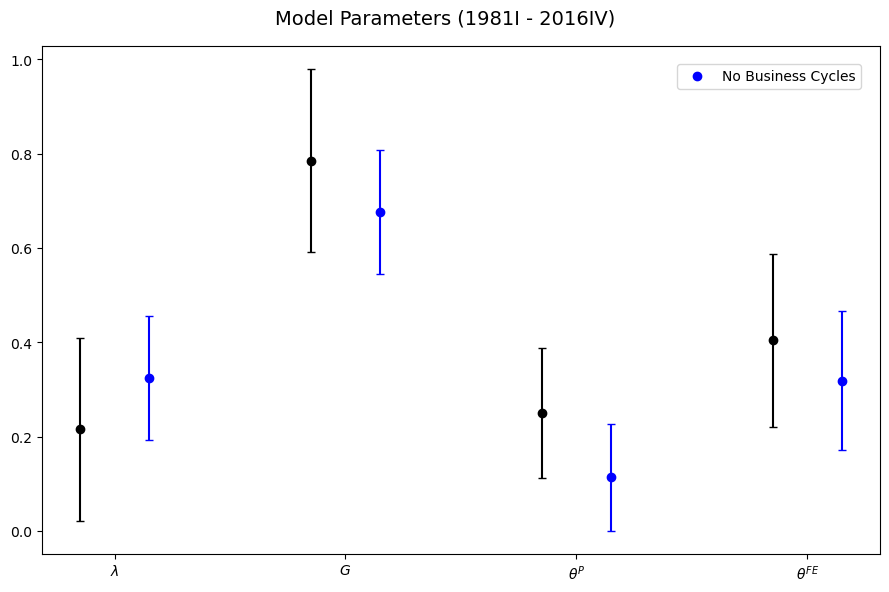

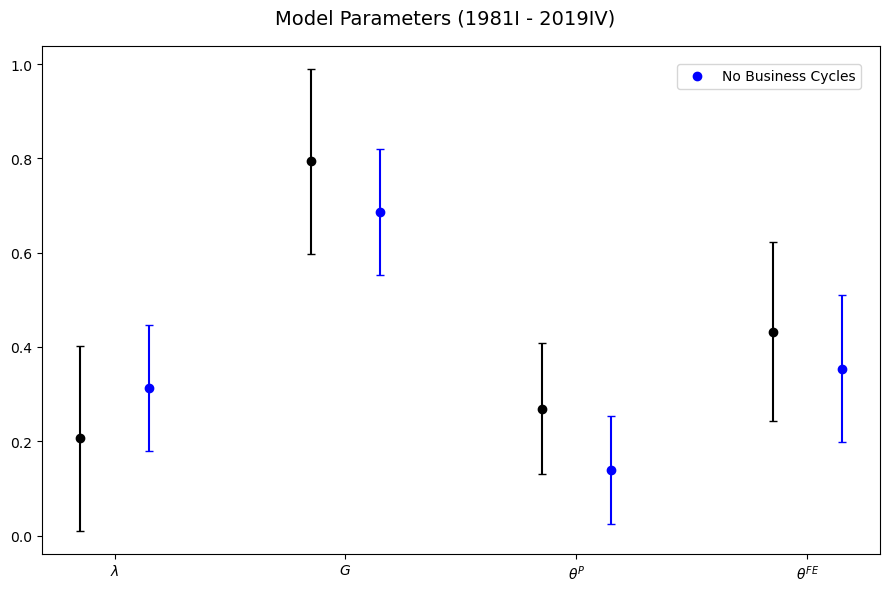

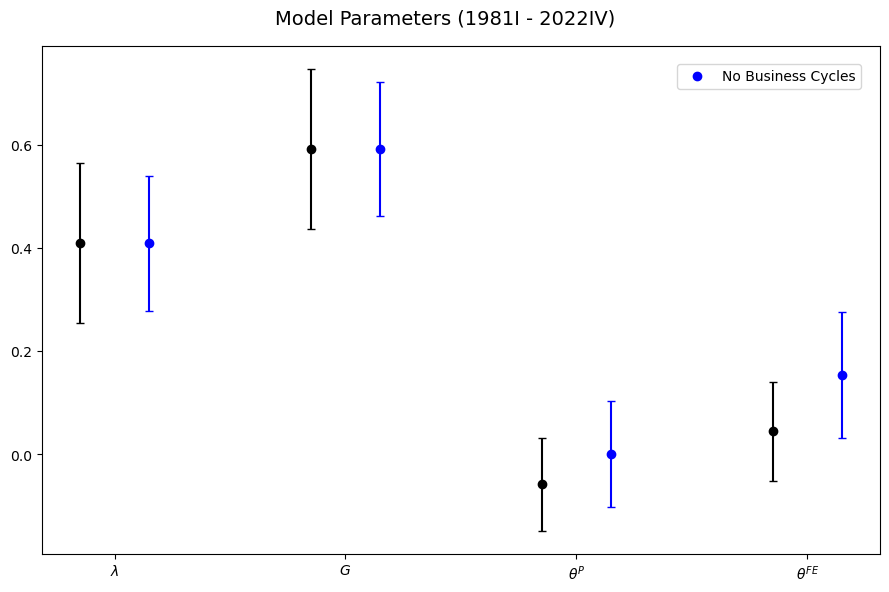

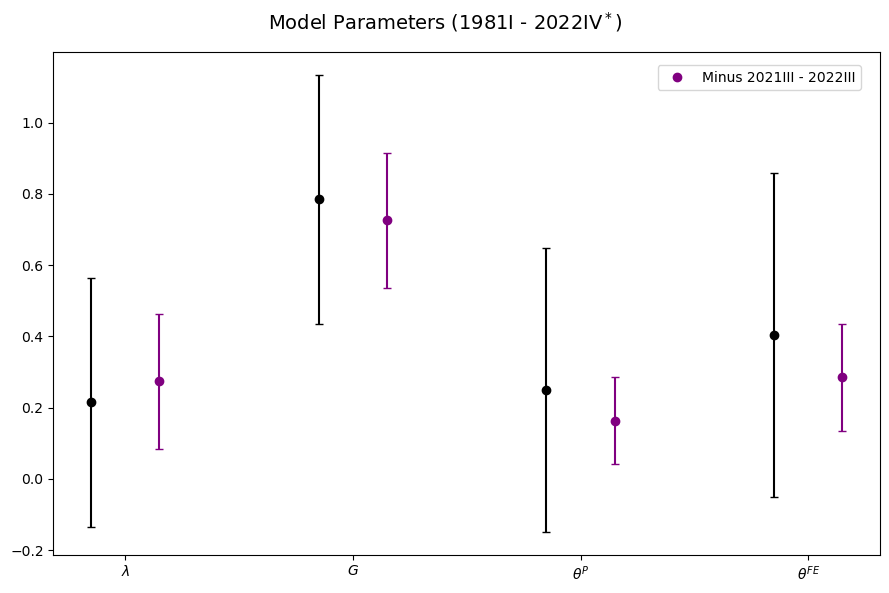

/var/folders/6q/zww1c4xj04d9c7jlxyz1zc6c0000gn/T/ipykernel_41693/2098407117.py:10: RuntimeWarning: invalid value encountered in sqrt
  params.append((-((2 * fe2) + 1) + np.sqrt(((2 * fe2) + 1)**2 - 4 * (fe2 + (fe2 * ar1**2) + 1) * fe2)) / (2 * (fe2 + (fe2 * ar1**2) + 1)))


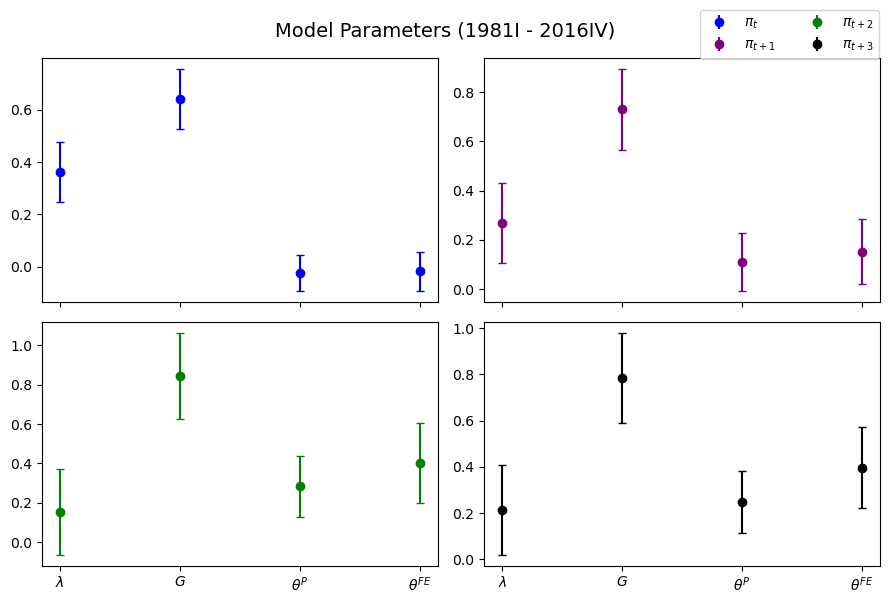

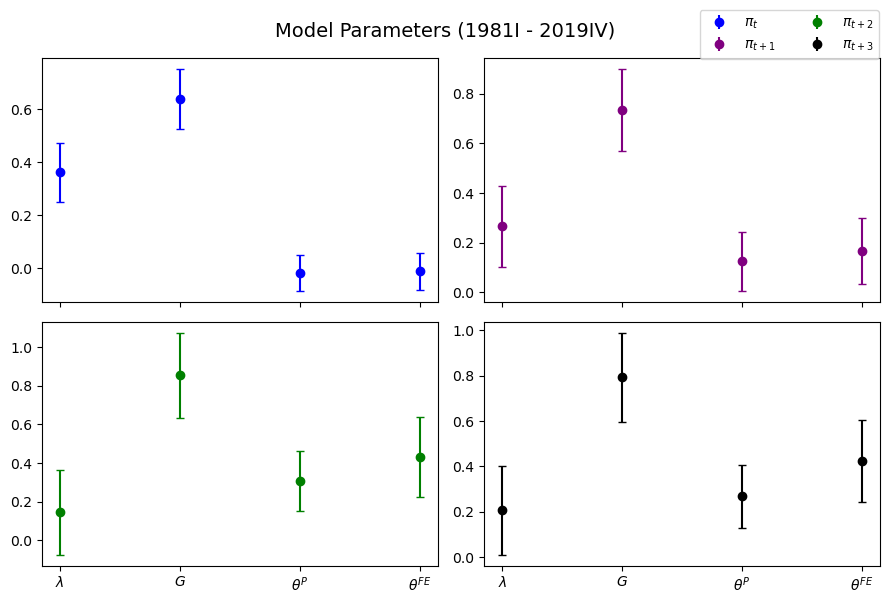

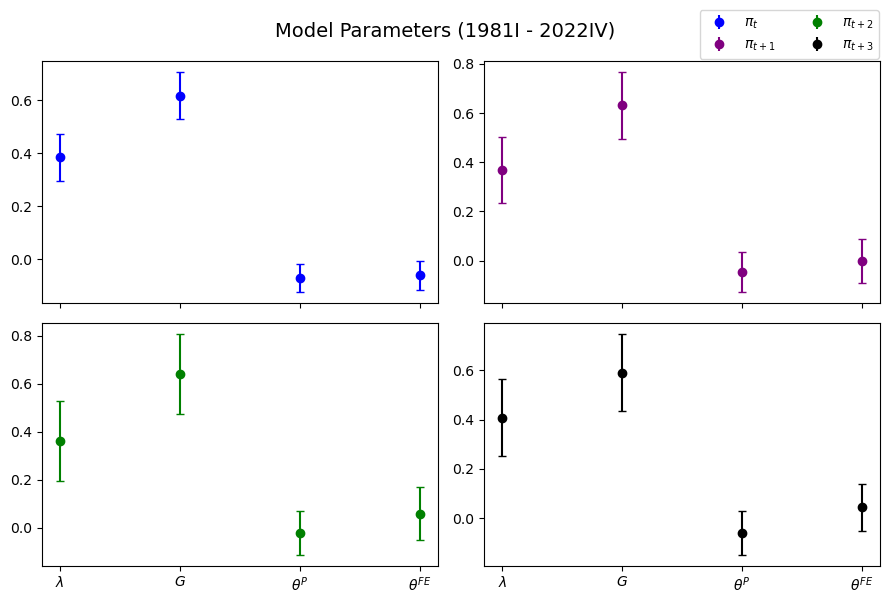

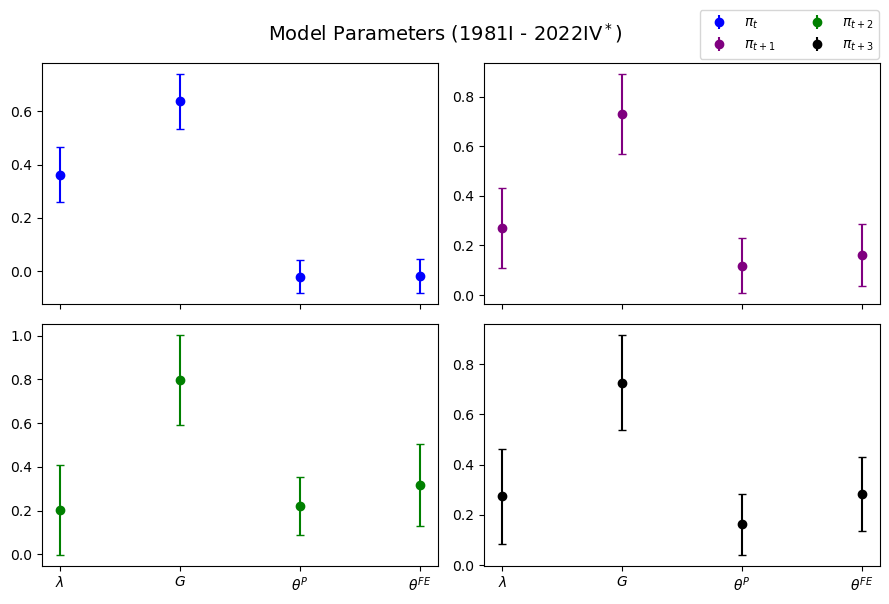

In [6]:
######################
   ## Parameters ##
######################
def params(ols, pldols, fe, fe2, ar1):
    params = []
    params.append(ols / (1 + ols))
    params.append(1 / (1 + ols))
    params.append((-((2 * pldols) + 1) + np.sqrt(((2 * pldols) + 1)**2 - 4 * (pldols + (pldols * ar1**2) + 1) * pldols)) / (2 * (pldols + (pldols * ar1**2) + 1)))
    params.append((-((2 * fe) + 1) + np.sqrt(((2 * fe) + 1)**2 - 4 * (fe + (fe * ar1**2) + 1) * fe)) / (2 * (fe + (fe * ar1**2) + 1)))
    params.append((-((2 * fe2) + 1) + np.sqrt(((2 * fe2) + 1)**2 - 4 * (fe2 + (fe2 * ar1**2) + 1) * fe2)) / (2 * (fe2 + (fe2 * ar1**2) + 1)))
    return params

def params_plot(date, parameter, parameter_nr, regs, regs_nr):
   n = [(regs[0][3].params[1] + 1.96 * regs[0][3].bse[1]), (regs[1][3].params[1] + 1.96 * regs[1][3].bse[1]), (regs[2][3].params[1] + 1.96 * regs[2][3].bse[1]), (regs[3][3].params[1] + 1.96 * regs[3][3].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]
   nr = [(regs_nr[0][3].params[1] + 1.96 * regs_nr[0][3].bse[1]), (regs_nr[1][3].params[1] + 1.96 * regs_nr[1][3].bse[1]), (regs_nr[2][3].params[1] + 1.96 * regs_nr[2][3].bse[1]), (regs_nr[3][3].params[1] + 1.96 * regs_nr[3][3].bse[1]), (regs_nr[4].params[1] + 1.96 * regs_nr[4].bse[1])]

   a = params(n[0], n[1], n[2], n[3], n[4])
   b = params(nr[0], nr[1], nr[2], nr[3], nr[4])
   errors = [(a[0]-parameter[0]), (b[0]-parameter_nr[0]), (a[1]-parameter[1]), (b[1]-parameter_nr[1]), (a[2]-parameter[2]), (b[2]-parameter_nr[2]), (a[3]-parameter[3]), (b[3]-parameter_nr[3])]
   
   fig, ax = plt.subplots(figsize=(9, 6))
   fig.suptitle(f'Model Parameters (1981I - {str(date)[0:4]}IV)', fontsize=14)
   
   handles = ax1.errorbar([], [], [], fmt='o', color='blue')
   labels = ['No Business Cycles']
   fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.70, 0.65, 0.27, 0.25))

   parameters = pd.DataFrame({'parameters': [parameter[0], parameter_nr[0], parameter[1], parameter_nr[1], parameter[2], parameter_nr[2], parameter[3], parameter_nr[3]]}, index=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)', '(7)', '(8)'])

   errors = {'(1)': abs(errors[0]), '(2)': abs(errors[1]), '(3)': abs(errors[2]), '(4)': abs(errors[3]), '(5)': abs(errors[4]), '(6)': abs(errors[5]), '(7)': abs(errors[6]), '(8)': abs(errors[7])}

   nr = ['(2)', '(4)', '(6)', '(8)']
   width = 0.4  # Adjust the width of the error bars
   
   for idx, i in enumerate(parameters.index):
      x = idx + 1
      if i in nr:
         ax.errorbar(x - width/2, parameters.loc[i, 'parameters'], errors[i], capsize=3, fmt='o', color='blue')
      else:
         ax.errorbar(x + width/2, parameters.loc[i, 'parameters'], errors[i], capsize=3, fmt='o', color='black')
    
   ax.set_xticks(range(1, len(parameters.index) + 1))
   ax.set_xticks([1.5, 3.5, 5.5, 7.5])
   ax.set_xticklabels([r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])
      
   plt.tight_layout()
   plt.show()
   fig.savefig(f'output/figures/parameters/parameters_{str(date)[0:4]}.png', dpi=200)
   

def params_plot22(date, parameter, parameter_nr, regs, regs_nr):
   n = [(regs[0][3].params[1] + 1.96 * regs[0][3].bse[1]), (regs[1][3].params[1] + 1.96 * regs[1][3].bse[1]), (regs[2][3].params[1] + 1.96 * regs[2][3].bse[1]), (regs[3][3].params[1] + 1.96 * regs[3][3].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]
   nr = [(regs_nr[0][3].params[1] + 1.96 * regs_nr[0][3].bse[1]), (regs_nr[1][3].params[1] + 1.96 * regs_nr[1][3].bse[1]), (regs_nr[2][3].params[1] + 1.96 * regs_nr[2][3].bse[1]), (regs_nr[3][3].params[1] + 1.96 * regs_nr[3][3].bse[1]), (regs_nr[4].params[1] + 1.96 * regs_nr[4].bse[1])]

   a = params(n[0], n[1], n[2], n[3], n[4])
   b = params(nr[0], nr[1], nr[2], nr[3], nr[4])
   errors = [(a[0]-parameter[0]), (b[0]-parameter_nr[0]), (a[1]-parameter[1]), (b[1]-parameter_nr[1]), (a[2]-parameter[2]), (b[2]-parameter_nr[2]), (a[3]-parameter[3]), (b[3]-parameter_nr[3])]
   
   fig, ax = plt.subplots(figsize=(9, 6))
   fig.suptitle(r'Model Parameters (1981I - 2022IV$^*$)', fontsize=14)
   handles = ax1.errorbar([], [], [], fmt='o', color='purple')
   labels = ['Minus 2021III - 2022III']
   fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.70, 0.65, 0.27, 0.25))

   parameters = pd.DataFrame({'parameters': [parameter[0], parameter_nr[0], parameter[1], parameter_nr[1], parameter[2], parameter_nr[2], parameter[3], parameter_nr[3]]}, index=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)', '(7)', '(8)'])

   errors = {'(1)': abs(errors[0]), '(2)': abs(errors[1]), '(3)': abs(errors[2]), '(4)': abs(errors[3]), '(5)': abs(errors[4]), '(6)': abs(errors[5]), '(7)': abs(errors[6]), '(8)': abs(errors[7])}

   nr = ['(2)', '(4)', '(6)', '(8)']
   width = 0.4  # Adjust the width of the error bars
   
   for idx, i in enumerate(parameters.index):
      x = idx + 1
      if i in nr:
         ax.errorbar(x - width/2, parameters.loc[i, 'parameters'], errors[i], capsize=3, fmt='o', color='purple')
      else:
         ax.errorbar(x + width/2, parameters.loc[i, 'parameters'], errors[i], capsize=3, fmt='o', color='black')
    
   ax.set_xticks(range(1, len(parameters.index) + 1))
   ax.set_xticks([1.5, 3.5, 5.5, 7.5])
   ax.set_xticklabels([r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])
      
   plt.tight_layout()
   plt.show()
   fig.savefig(f'output/figures/parameters/parameters_2022_ncovid.png', dpi=200)
   
   
def params_plot_quad(date, regs):
   nt0 = [(regs[0][0].params[1] + 1.96 * regs[0][0].bse[1]), (regs[1][0].params[1] + 1.96 * regs[1][0].bse[1]), (regs[2][0].params[1] + 1.96 * regs[2][0].bse[1]), (regs[3][0].params[1] + 1.96 * regs[3][0].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]
   nt1 = [(regs[0][1].params[1] + 1.96 * regs[0][1].bse[1]), (regs[1][1].params[1] + 1.96 * regs[1][1].bse[1]), (regs[2][1].params[1] + 1.96 * regs[2][1].bse[1]), (regs[3][1].params[1] + 1.96 * regs[3][1].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]
   nt2 = [(regs[0][2].params[1] + 1.96 * regs[0][2].bse[1]), (regs[1][2].params[1] + 1.96 * regs[1][2].bse[1]), (regs[2][3].params[1] + 1.96 * regs[2][2].bse[1]), (regs[3][2].params[1] + 1.96 * regs[3][2].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]
   nt3 = [(regs[0][3].params[1] + 1.96 * regs[0][3].bse[1]), (regs[1][3].params[1] + 1.96 * regs[1][3].bse[1]), (regs[2][3].params[1] + 1.96 * regs[2][3].bse[1]), (regs[3][3].params[1] + 1.96 * regs[3][3].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]

   a0 = params(nt0[0], nt0[1], nt0[2], nt0[3], nt0[4])
   a1 = params(nt1[0], nt1[1], nt1[2], nt1[3], nt1[4])
   a2 = params(nt2[0], nt2[1], nt2[2], nt2[3], nt2[4])
   a3 = params(nt3[0], nt3[1], nt3[2], nt3[3], nt3[4])
   
   parameter = [params(regs[0][0].params[1], regs[1][0].params[1], regs[2][0].params[1], regs[3][0].params[1], regs[4].params[1]), params(regs[0][1].params[1], regs[1][1].params[1], regs[2][1].params[1], regs[3][1].params[1], regs[4].params[1]), params(regs[0][2].params[1], regs[1][2].params[1], regs[2][2].params[1], regs[3][2].params[1], regs[4].params[1]), params(regs[0][3].params[1], regs[1][3].params[1], regs[2][3].params[1], regs[3][3].params[1], regs[4].params[1])]
   
   errors0 = [(a0[0]-parameter[0][0]), (a0[1]-parameter[0][1]), (a0[2]-parameter[0][2]), (a0[3]-parameter[0][3]), (a0[4]-parameter[0][4])]
   errors1 = [(a1[0]-parameter[1][0]), (a1[1]-parameter[1][1]), (a1[2]-parameter[1][2]), (a1[3]-parameter[1][3]), (a1[4]-parameter[1][4])]
   errors2 = [(a2[0]-parameter[2][0]), (a2[1]-parameter[2][1]), (a2[2]-parameter[2][2]), (a2[3]-parameter[2][3]), (a2[4]-parameter[2][4])]
   errors3 = [(a3[0]-parameter[3][0]), (a3[1]-parameter[3][1]), (a3[2]-parameter[3][2]), (a3[3]-parameter[3][3]), (a3[4]-parameter[3][4])]
   
   fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 6), sharex=True)
   fig.suptitle(f'Model Parameters (1981I - {str(date)[0:4]}IV)', fontsize=14)
   handles = [ax1.errorbar([], [], [], fmt='o', color=color) for color in ['blue', 'purple', 'green', 'black']]
   labels = [r'$\pi_t$', r'$\pi_{t+1}$', r'$\pi_{t+2}$', r'$\pi_{t+3}$']
   fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.76, 0.76, 0.23, 0.25), ncol=2)

   parameters0 = pd.DataFrame({'parameters': [parameter[0][0], parameter[0][1], parameter[0][2], parameter[0][3]]}, index=[r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])
   parameters1 = pd.DataFrame({'parameters': [parameter[1][0], parameter[1][1], parameter[1][2], parameter[1][3]]}, index=[r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])
   parameters2 = pd.DataFrame({'parameters': [parameter[2][0], parameter[2][1], parameter[2][2], parameter[2][3]]}, index=[r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])
   parameters3 = pd.DataFrame({'parameters': [parameter[3][0], parameter[3][1], parameter[3][2], parameter[3][3]]}, index=[r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])

   error0 = {r'$\lambda$': abs(errors0[0]), r'$G$': abs(errors0[1]), r'$\theta^P$': abs(errors0[2]), r'$\theta^{FE}$': abs(errors0[3])}
   error1 = {r'$\lambda$': abs(errors1[0]), r'$G$': abs(errors1[1]), r'$\theta^P$': abs(errors1[2]), r'$\theta^{FE}$': abs(errors1[3])}
   error2 = {r'$\lambda$': abs(errors2[0]), r'$G$': abs(errors2[1]), r'$\theta^P$': abs(errors2[2]), r'$\theta^{FE}$': abs(errors2[3])}
   error3 = {r'$\lambda$': abs(errors3[0]), r'$G$': abs(errors3[1]), r'$\theta^P$': abs(errors3[2]), r'$\theta^{FE}$': abs(errors3[3])}

   for i in parameters0.index:
      ax1.errorbar(f'{i}', parameters0.loc[f'{i}', 'parameters'], error0[i], capsize=3, fmt='o', color='blue')
   for i in parameters1.index:
      ax2.errorbar(f'{i}', parameters1.loc[f'{i}', 'parameters'], error1[i], capsize=3, fmt='o', color='purple')
   for i in parameters2.index:
      ax3.errorbar(f'{i}', parameters2.loc[f'{i}', 'parameters'], error2[i], capsize=3, fmt='o', color='green')
   for i in parameters3.index:
      ax4.errorbar(f'{i}', parameters3.loc[f'{i}', 'parameters'], error3[i], capsize=3, fmt='o', color='k')
      
   plt.tight_layout()
   plt.show()
   fig.savefig(f'output/figures/parameters/quad/parameters_{str(date)[0:4]}_quad.png', dpi=200)


def params_plot_quad22(date, regs):
   nt0 = [(regs[0][0].params[1] + 1.96 * regs[0][0].bse[1]), (regs[1][0].params[1] + 1.96 * regs[1][0].bse[1]), (regs[2][0].params[1] + 1.96 * regs[2][0].bse[1]), (regs[3][0].params[1] + 1.96 * regs[3][0].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]
   nt1 = [(regs[0][1].params[1] + 1.96 * regs[0][1].bse[1]), (regs[1][1].params[1] + 1.96 * regs[1][1].bse[1]), (regs[2][1].params[1] + 1.96 * regs[2][1].bse[1]), (regs[3][1].params[1] + 1.96 * regs[3][1].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]
   nt2 = [(regs[0][2].params[1] + 1.96 * regs[0][2].bse[1]), (regs[1][2].params[1] + 1.96 * regs[1][2].bse[1]), (regs[2][3].params[1] + 1.96 * regs[2][2].bse[1]), (regs[3][2].params[1] + 1.96 * regs[3][2].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]
   nt3 = [(regs[0][3].params[1] + 1.96 * regs[0][3].bse[1]), (regs[1][3].params[1] + 1.96 * regs[1][3].bse[1]), (regs[2][3].params[1] + 1.96 * regs[2][3].bse[1]), (regs[3][3].params[1] + 1.96 * regs[3][3].bse[1]), (regs[4].params[1] + 1.96 * regs[4].bse[1])]

   a0 = params(nt0[0], nt0[1], nt0[2], nt0[3], nt0[4])
   a1 = params(nt1[0], nt1[1], nt1[2], nt1[3], nt1[4])
   a2 = params(nt2[0], nt2[1], nt2[2], nt2[3], nt2[4])
   a3 = params(nt3[0], nt3[1], nt3[2], nt3[3], nt3[4])
   
   parameter = [params(regs[0][0].params[1], regs[1][0].params[1], regs[2][0].params[1], regs[3][0].params[1], regs[4].params[1]), params(regs[0][1].params[1], regs[1][1].params[1], regs[2][1].params[1], regs[3][1].params[1], regs[4].params[1]), params(regs[0][2].params[1], regs[1][2].params[1], regs[2][2].params[1], regs[3][2].params[1], regs[4].params[1]), params(regs[0][3].params[1], regs[1][3].params[1], regs[2][3].params[1], regs[3][3].params[1], regs[4].params[1])]
   
   errors0 = [(a0[0]-parameter[0][0]), (a0[1]-parameter[0][1]), (a0[2]-parameter[0][2]), (a0[3]-parameter[0][3]), (a0[4]-parameter[0][4])]
   errors1 = [(a1[0]-parameter[1][0]), (a1[1]-parameter[1][1]), (a1[2]-parameter[1][2]), (a1[3]-parameter[1][3]), (a1[4]-parameter[1][4])]
   errors2 = [(a2[0]-parameter[2][0]), (a2[1]-parameter[2][1]), (a2[2]-parameter[2][2]), (a2[3]-parameter[2][3]), (a2[4]-parameter[2][4])]
   errors3 = [(a3[0]-parameter[3][0]), (a3[1]-parameter[3][1]), (a3[2]-parameter[3][2]), (a3[3]-parameter[3][3]), (a3[4]-parameter[3][4])]
   
   fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 6), sharex=True)
   fig.suptitle(r'Model Parameters (1981I - 2022IV$^*$)', fontsize=14)
   handles = [ax1.errorbar([], [], [], fmt='o', color=color) for color in ['blue', 'purple', 'green', 'black']]
   labels = [r'$\pi_t$', r'$\pi_{t+1}$', r'$\pi_{t+2}$', r'$\pi_{t+3}$']
   fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.76, 0.76, 0.23, 0.25), ncol=2)

   parameters0 = pd.DataFrame({'parameters': [parameter[0][0], parameter[0][1], parameter[0][2], parameter[0][3]]}, index=[r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])
   parameters1 = pd.DataFrame({'parameters': [parameter[1][0], parameter[1][1], parameter[1][2], parameter[1][3]]}, index=[r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])
   parameters2 = pd.DataFrame({'parameters': [parameter[2][0], parameter[2][1], parameter[2][2], parameter[2][3]]}, index=[r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])
   parameters3 = pd.DataFrame({'parameters': [parameter[3][0], parameter[3][1], parameter[3][2], parameter[3][3]]}, index=[r'$\lambda$', r'$G$', r'$\theta^P$', r'$\theta^{FE}$'])

   error0 = {r'$\lambda$': abs(errors0[0]), r'$G$': abs(errors0[1]), r'$\theta^P$': abs(errors0[2]), r'$\theta^{FE}$': abs(errors0[3])}
   error1 = {r'$\lambda$': abs(errors1[0]), r'$G$': abs(errors1[1]), r'$\theta^P$': abs(errors1[2]), r'$\theta^{FE}$': abs(errors1[3])}
   error2 = {r'$\lambda$': abs(errors2[0]), r'$G$': abs(errors2[1]), r'$\theta^P$': abs(errors2[2]), r'$\theta^{FE}$': abs(errors2[3])}
   error3 = {r'$\lambda$': abs(errors3[0]), r'$G$': abs(errors3[1]), r'$\theta^P$': abs(errors3[2]), r'$\theta^{FE}$': abs(errors3[3])}

   for i in parameters0.index:
      ax1.errorbar(f'{i}', parameters0.loc[f'{i}', 'parameters'], error0[i], capsize=3, fmt='o', color='blue')
   for i in parameters1.index:
      ax2.errorbar(f'{i}', parameters1.loc[f'{i}', 'parameters'], error1[i], capsize=3, fmt='o', color='purple')
   for i in parameters2.index:
      ax3.errorbar(f'{i}', parameters2.loc[f'{i}', 'parameters'], error2[i], capsize=3, fmt='o', color='green')
   for i in parameters3.index:
      ax4.errorbar(f'{i}', parameters3.loc[f'{i}', 'parameters'], error3[i], capsize=3, fmt='o', color='k')
      
   plt.tight_layout()
   plt.show()
   fig.savefig(f'output/figures/parameters/quad/parameters_2022n_quad.png', dpi=200)
   
   
params_plot('2016-12-31', parameters_2016, parameters_2016_nr, regs_2016, regs_2016_nr)
params_plot('2019-12-31', parameters_2019, parameters_2019_nr, regs_2019, regs_2019_nr)
params_plot('2022-12-31', parameters_2022, parameters_2022_nr, regs_2022, regs_2022_nr)
params_plot22('2022-12-31', parameters_2016, parameters_2022n, regs_2022, regs_2022n)

params_plot_quad('2016-12-31', regs_2016)
params_plot_quad('2019-12-31', regs_2019)
params_plot_quad('2022-12-31', regs_2022)
params_plot_quad22('2022-12-31', regs_2022n)